In [17]:
import pandas as pd
import numpy as np
import argparse
import configparser
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter
from scipy import integrate
from scipy.interpolate import UnivariateSpline
import scipy.stats as stats
import astropy.constants as const

In [18]:
def parse_config():    
    parser = argparse.ArgumentParser()    
    parser.add_argument('--config', required=True)    
    args = parser.parse_args(["--config", "config.ini"])
    config = configparser.ConfigParser() 
    config.read(args.config) 
    return config
    
def make_clean():    
    global galaxy_csv_name, GW_csv_name, deg_or_rad, GW_data_size, galaxy_data_size, redshift_min, redshift_bin_size, luminosity_bin_min, luminosity_bin_size, theta_max, nside, z_bin_num, d_L_bin_num, r2dr, nthreads
    galaxy_csv_name = config['Config'].get('galaxy_csv_name')
    GW_csv_name = config['Config'].get('GW_csv_name')
    deg_or_rad = config['Config'].get('deg_or_rad')
    GW_data_size = config['Config'].getint('GW_data_size')    
    galaxy_data_size = config['Config'].getint('galaxy_data_size')    
    redshift_min = config['Config'].getfloat('redshift_min')    
    redshift_bin_size = config['Config'].getfloat('redshift_bin_size')
    luminosity_bin_min = config['Config'].getfloat('luminosity_bin_min')
    luminosity_bin_size = config['Config'].getfloat('luminosity_bin_size')
    theta_max = config['Config'].getfloat('theta_max')
    nside = config['Config'].getint('nside')
    z_bin_num = config['Config'].getint('z_bin_num')
    d_L_bin_num = config['Config'].getint('d_L_bin_num')
    r2dr = config['Config'].getint('random_2_data_ratio')
    nthreads = config['Config'].getint('nthreads')

In [19]:
#get variables from config file
config = parse_config()
make_clean()

In [20]:
df = pd.read_csv(
    "output_with_inj.csv",
    skiprows=17   # skips lines before "ws,stdevs"
)

ws = df["ws"].to_numpy()
stdevs = df["stdevs"].to_numpy()

In [21]:
#splits w and stdevs into the different d_L bins
split_w = np.array_split(np.array(ws),d_L_bin_num)
split_stdevs = np.array_split(np.array(stdevs),d_L_bin_num)

In [22]:
#finds factors closest to the square root of the input number (used to make the subplots look better)
def find_factors(num):
    sqrt_num = np.sqrt(num)
    if sqrt_num % 1 == 0:
        high_factor = int(sqrt_num)
        low_factor = int(sqrt_num)
    else:
        low_num = num // sqrt_num
        while num % low_num != 0:
            low_num = low_num - 1
        low_factor = int(low_num)
        high_factor = int(num / low_factor)
    return low_factor, high_factor

In [23]:
#defines gaussian
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

1.660121187058614
[ 3  6  9 12 16 18]
1.108002464982492
[ 2  5  8 11 14 16]
1.0649091867369291
[ 3  5  9 11 18]
1.0500049122426067
[ 3  5  7  9 14]
0.9407608071335916
[ 2  5  7  9 11 14 16]
1.0435179045760066
[ 2  5  7  9 11 14]


/home/vboxuser/miniconda3/envs/corrfunc_env/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:989: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
/tmp/ipykernel_33992/2739388650.py:38: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussian, x_data, y_data, sigma=y_error, absolute_sigma=True, p0 = [A0, mu0, redshift_bin_size])


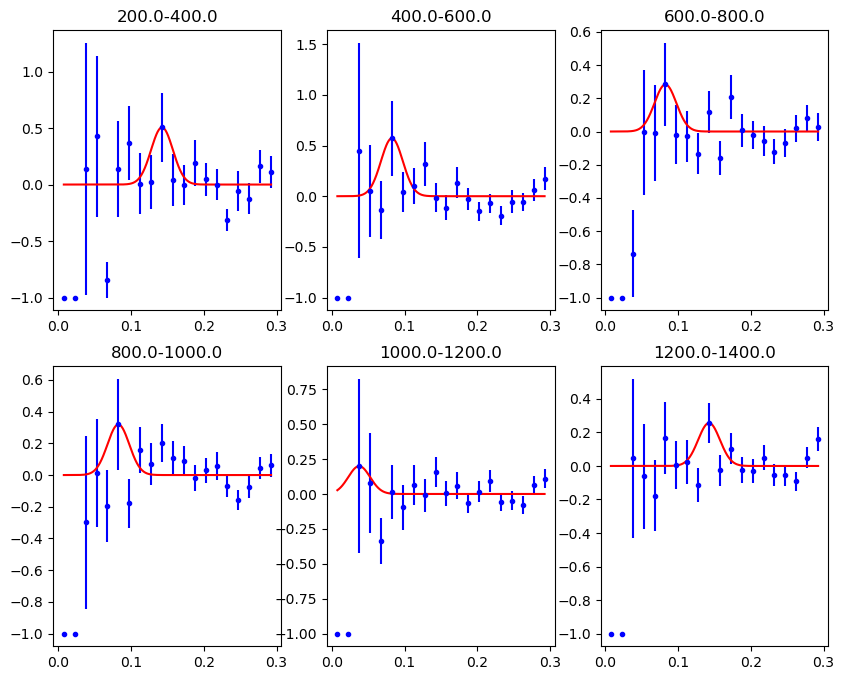

In [25]:
#each subplot is a d_L bin and graphs the w value for each redshift bin with a gaussian fit
z_min = redshift_min + redshift_bin_size/2
z_max = redshift_min + z_bin_num * redshift_bin_size - redshift_bin_size/2
z_values = np.array(np.linspace(z_min,z_max,z_bin_num))
sp_rows, sp_columns = find_factors(d_L_bin_num)
fig,axs = plt.subplots(sp_rows,sp_columns,figsize=(10,8))
z_means_est = []
stdev_est = []

for m in range(sp_rows):
    for n in range(sp_columns):
        i = m*sp_columns + n
        d_L_min = luminosity_bin_size*i+luminosity_bin_min
        d_L_max = d_L_min + luminosity_bin_size
        title = str(d_L_min) + "-" + str(d_L_max)
        x_data = z_values
        y_data = np.ravel(split_w[i])
        y_error = split_stdevs[i]
        #z_mean = z_means[i]

        #y_smooth = savgol_filter(y_data, 9, 2)
        #start_cut = 0
        #peaks, _ = find_peaks(y_smooth[start_cut:], prominence=0.1)
        #peak_idx = start_cut + peaks[np.argmax(y_smooth[start_cut:][peaks])]

        inverse_error = np.where(y_error>0)
        #print(inverse_error)
        z_stdev = np.std((y_data[inverse_error] - np.average(y_data[inverse_error]))/y_error[inverse_error])
        print(z_stdev)
        
        peaks, _ = find_peaks(y_data, height=None, prominence=[0, z_stdev])
        print(peaks)
        peak_idx = peaks[np.argmax(y_data[peaks])]
        mu0 = x_data[peak_idx]
        #print(x_data[np.argmax(y_data)],mu0,x_data[peaks])
        A0 = y_data[peak_idx]

        popt, pcov = curve_fit(gaussian, x_data, y_data, sigma=y_error, absolute_sigma=True, p0 = [A0, mu0, redshift_bin_size])
        A_fit, mu_fit, sigma_fit = popt
        z_means_est.append(mu_fit)
        stdev_est.append(abs(sigma_fit))
        g_x_fit = np.linspace(min(x_data), max(x_data), 500)
        g_y_fit = gaussian(g_x_fit, *popt)
        
        axs[m,n].errorbar(x_data, y_data, yerr=y_error, fmt='.', color='b')
        #axs[m,n].axvline(z_mean,linestyle='--',color='k')
        axs[m,n].plot(g_x_fit, g_y_fit, label='Gaussian fit', color='r')
        axs[m,n].set_title(title)

In [26]:
def lum_dist(z, H0, Omega_m=0.307115):
    def integrand(zp):
        return 1.0 / np.sqrt(1.0 - Omega_m + Omega_m * (1.0 + zp) ** 3)
    integrals = np.array([integrate.quad(integrand, 0, zz)[0] for zz in z])
    dL = (c_kms * (1.0 + z) / H0) * integrals
    return dL

In [27]:
c_kms = const.c.to('km/s').value

d_L_repeat = np.reshape(np.repeat(d_L_means, 10, axis=None), (len(z_means_est),-1))

popt, pcov = curve_fit(lum_dist, z_means_est, d_L_means, p0=[70], absolute_sigma=True)
H_fit = popt[0]
perr = np.sqrt(np.diag(pcov))
x_fit = np.linspace(0.05, 0.275, 500)
y_fit = lum_dist(x_fit, *popt)

plt.errorbar(z_means_est, d_L_means, xerr=stdev_est, fmt='.', color='b')
plt.plot(x_fit, y_fit, label="linear fit", color='k')
plt.xlabel("redshift")
plt.ylabel("luminosity distance")
plt.show()

print(f"Fit results:")
print(f"H_0     = {H_fit:.3f} ± {perr[0]:.3f}")
print(stdev_est)

NameError: name 'd_L_means' is not defined